In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from scipy.integrate import quad

In [2]:
def info_fraction(epsilon, b):
    """
    Computes the Fisher Information Fraction F(epsilon, beta) 
    using the expanded score variance integral.
    """
    # Boundary conditions
    if epsilon == 0: return 1.0
    if epsilon == 1: return 0.0
    
    # Avoid the removable algebraic singularity where lambda = 1
    if np.isclose(epsilon, 1 - b):
        epsilon += 1e-6 
        
    lam = b / (1 - epsilon)
    
    def integrand(t):
        # Clip t strictly above 0 to prevent float overflow on negative exponents
        t = max(t, 1e-12) 
        
        t_pow = t**(lam - 1)
        
        # Marginal Density g(t; beta)
        g = (epsilon * lam) / (lam - 1) + (lam * (b - 1) / (lam - 1)) * t_pow
        
        # Score internal fraction components
        num = (b - 1) * t_pow * np.log(t) - (epsilon / (lam - 1)) * (1 - t_pow)
        den = epsilon + (b - 1) * t_pow
        
        # Combined squared bracket
        s = 1 + lam * (num / den)
        
        return g * (s**2)

    # Integrate over the support of the thinned p-value
    res, _ = quad(integrand, 0, 1, limit=200)
    return res

v_info_fraction = np.vectorize(info_fraction)

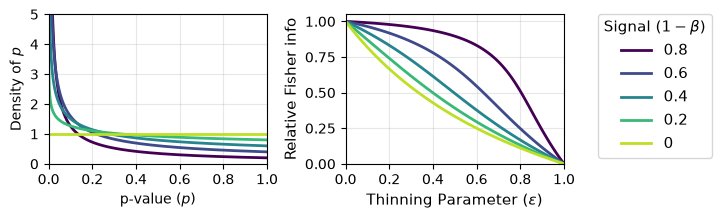

In [4]:
beta_values = [0.2, 0.4, 0.6, 0.8, 1]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(beta_values)))

fig, axes = plt.subplots(1, 2, figsize=(7, 2.3))

# --- LEFT PLOT: Beta(beta, 1) Densities ---
ax1 = axes[0]
x_p = np.linspace(0.001, 1, 500)

for b, color in zip(beta_values, colors):
    y_pdf = beta_dist.pdf(x_p, b, 1)
    ax1.plot(x_p, y_pdf, label=rf'${np.round(1 - b, 2)}$', color=color, lw=2)

# ax1.set_title(r'Density of $p \sim \mathrm{Beta}(\beta, 1)$', fontsize=12)
ax1.set_xlabel(r'p-value ($p$)', fontsize=10)
ax1.set_ylabel(r'Density of $p$', fontsize=10)
ax1.set_ylim(0, 5) 
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

# --- RIGHT PLOT: Information Fraction ---
ax2 = axes[1]
x_eps = np.linspace(0, 1, 100)

for b, color in zip(beta_values, colors):
    y_frac = v_info_fraction(x_eps, b)
    ax2.plot(x_eps, y_frac, label=rf'${np.round(1 - b, 2)}$', color=color, lw=2)

# ax2.set_title(r'Information Fraction $\mathcal{F}(\epsilon, \beta)$', fontsize=12)
ax2.set_xlabel(r'Thinning Parameter ($\epsilon$)', fontsize=11)
ax2.set_ylabel('Relative Fisher info', fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.set_xlim(0, 1)
ax2.grid(True, alpha=0.3)

# # Extract handles and labels from the first axis (they are identical)
handles, labels = ax1.get_legend_handles_labels()

fig.legend(handles, labels, 
           title=r"Signal ($1-\beta$)", 
           loc='center left',
           frameon=True,
           bbox_to_anchor=(0.85, 0.6),
           ncol=1, 
           fontsize=11, 
           title_fontsize=11)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("../figures/fisher_info.png", dpi=300, bbox_inches='tight')
plt.show()